# Beyond BLAST Notebook

In [1]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Revise 

using Base.Threads, NPZ, DataInterpolations, Interpolations, FastChebInterp
using BenchmarkTools, FFTW, FastTransforms, Dates, TOML, Plots, Plots.Measures
using QuadGK, LaTeXStrings, Tullio, StaticArrays, LoopVectorization, LinearAlgebra
using Unitful, SpecialFunctions, DifferentialEquations, Cosmology, NumericalIntegration
using CSV, DataFrames, JSON, OrderedCollections
;

[ Info: Precompiling DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0]
Precompiling packages...
   2685.1 ms  ✓ DataInterpolations → DataInterpolationsChainRulesCoreExt
  1 dependency successfully precompiled in 4 seconds. 37 already precompiled.
[ Info: Precompiling DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd]
┌ Warning: Module DataInterpolations with build ID fafbfcfd-bf49-cef3-8f1e-804f2038eae0 is missing from the cache.
│ This may mean DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2022
[ Info: Skipping precompilation since __precompile__(false). Importing DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd].
Precompiling packages...
    641.5 ms  ✓ FastChebInterp
  1 dependency successfully precompiled in 1 seconds. 18 already precompiled.
[ Info: Precompiling FastChebInterp [cf66c380-9a80-432c-aff8-4f9c79c0bdde]
Precompi

#### Including the .jl modules

In [2]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
using .Blast
using .blast_tutorials
include("blast_code/src/galaxy_galaxy.jl")
include("blast_code/src/shear_shear.jl")
using .galaxy_galaxy
using .shear_shear

#### Defining an output run

In [4]:
timestamp = Dates.format(now(), "yyyy_mm_dd_HHMMSS")
output_dir = "out/runs/run_$timestamp"
plot_subdir = joinpath(output_dir, "plots")
Sl_plots = joinpath(plot_subdir, "Sl_plots")
Kernel_plots = joinpath(plot_subdir, "kernels")
quantity_subdir = joinpath(output_dir, "quantities")
chebcoefs = joinpath(quantity_subdir, "chebcoefs")
Sl = joinpath(quantity_subdir, "Sl")
mkpath(output_dir)
mkpath(plot_subdir)
mkpath(quantity_subdir)
mkpath(chebcoefs)
mkpath(Sl)
mkpath(Sl_plots)
mkpath(Kernel_plots)
println("Folders in place: ", output_dir, ", ", plot_subdir, " and ", quantity_subdir)

Folders in place: out/runs/run_2026_07_01_160422, out/runs/run_2026_07_01_160422/plots and out/runs/run_2026_07_01_160422/quantities


### Getting background quantities:

redshift $z$, comoving distance $\chi(z)$

In [5]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
x_b = npzread("blast_code/data/background/chi.npy") # array
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz") # array
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, x_b); # z(χ)
chi_of_z = DataInterpolations.AkimaInterpolation(x_b, z_b); # χ(z)

#### Setting parameters

In [ ]:
cosmo = Blast.FlatΛCDM()
N = 2^15+1                           # Number of comoving distance points
x = LinRange(26, 7000, N)            # in Mpc/h: from 26 Mpc/h to 7000 Mpc/h
xmin = minimum(x)                   # minimum comoving distance [Mpc/h]
xmax = maximum(x)                   # maximum comoving distance [Mpc/h]
z = z_of_χ.(x)
zmin = minimum(z)                    # minimum redshift
zmax = maximum(z)                    # maximum redshift
ℓ = LinRange(2, 200, 100)
Nk = 96
Nkp = 48
Nkpp = 48
kmax = 200/13                        # maximum wavenumber (small scales) [h/Mpc]
kmin = 2.5/xmax                     # minimum wavenumber (large scales) [h/Mpc]
n_cheb = 101                         # number of Chebyshev nodes 
;

#### Setting the value of sorting

In [7]:
sorting = false
if sorting == true
    k_grid_sort = sort(Blast.get_clencurt_grid(kmin, kmax, Nk))
    kp_grid_sort = sort(Blast.get_clencurt_grid(kmin, kmax, Nkp))
    kpp_grid_sort = sort(Blast.get_clencurt_grid(kmin, kmax, Nkpp))
    k_grid = k_grid_sort
    kp_grid = kp_grid_sort
    kpp_grid = kpp_grid_sort
else
    k_grid = Blast.get_clencurt_grid(kmin, kmax, Nk)
    kp_grid = Blast.get_clencurt_grid(kmin, kmax, Nkp)
    kpp_grid = Blast.get_clencurt_grid(kmin, kmax, Nkpp)
end
;

#### Configuration settings

In [ ]:
using OrderedCollections

params_run = OrderedDict(
    "number of points for the integration of the integrals of W, N" => N,
    "minimum comoving distance x_min" => x_min,
    "maximum comoving distance xmax" => xmax,
    "minimum redshift zmin" => zmin,
    "maximum redshift zmax" => zmax,
    "minimum wavenumber kmin" => kmin,
    "maximum wavenumber kmax" => kmax,
    "number of Chebyshev nodes n_cheb" => n_cheb,
    "number of ℓ values" => length(ℓ),
    "number of k points Nk" => Nk,
    "number of kp points Nkp" => Nkp,
    "number of kpp points Nkpp" => Nkpp
)



open(joinpath(output_dir, "config.txt"), "w") do dictio
    println(dictio, "=== Run parameters ===")
    for (key, val) in params_run
        println(dictio, key, " => ", val)
    end
    println(dictio)
    println(dictio, "=== Additional info ===")
    println(dictio, "comoving distance array x has size: ", length(x))
    println(dictio, "redshift array z has size: ", length(z))

    if k_grid != kp_grid
        println(dictio, "k_grid and kp_grid are different")
    else
        println(dictio, "k_grid and kp_grid are the same")
    end
    if k_grid != kpp_grid
        println(dictio, "k_grid and kpp_grid are different")
    else
        println(dictio, "k_grid and kpp_grid are the same")
    end
    if kp_grid != kpp_grid
        println(dictio, "kp_grid and kpp_grid are different")
    else
        println(dictio, "kp_grid and kpp_grid are the same")
    end

    if sorting == false
        println(dictio, "k_grid is not sorted")
    else
        println(dictio, "k_grid is sorted")
    end
end

println("Data brought to safety in folder: ", output_dir)


Data brought to safety in folder: out/runs/run_2026_07_01_160422


### Shear factor

In [9]:
#shear_prefac_W = shear_shear.shear_prefactor(x, z, cosmo; output_dir=output_dir);
#shear_prefac_W_cheb = shear_shear.shear_prefactor_cheb(zmin, zmax, n_cheb, z, shear_prefac_W; output_dir=output_dir);
#cheb_coeff_shear = shear_shear.compute_prefactor_chebcoeffs(shear_prefac_W_cheb; output_dir=output_dir);

### Galaxy clustering factor

Defining the kernel/window function for a galaxy probe: the window function is \
\
$W(z) = n(z) \chi(z)^2 b(z) D(z) $ \
\
where \
\
$n(z) = A (\frac{z}{z_0})^{\alpha} exp[{-(\frac{z}{z_0})^{\beta}}] $, \
\
with $A = \frac{1.5}{z_0}$, $\alpha = 2$ and $\beta = 1.5$ \
\
$b(z) = b_0 \sqrt{1+z} $ and $b_0 = 1$ \
\
$D(z) = \frac{D(z)^{unnorm}}{D(0)^{unnorm}}$, \
\
with $D(z)^{unnorm} = E(z) \int_z^{\infty} dz' \frac{1+z'}{E(z')^3} $ 

As for the ````gal_prefactor_W_cheb````, it is obtained interpolating each factor, ````bias````, ````growth````, ````nz_norm````, ````chi```` on the ````z````, and then obtaining the total interpolated product ````gal_prefact_W_cheb````.

As for the ````cheb_coeff_gal````, I compute this similarly to Blast: I define a ````plan```` object that takes the ````gal_prefact_W_cheb```` as input, and then returns the ````cheb_coeff```` as the output of the functions ````fast_chebcoefs````

In [10]:
gal_prefact_W, bias, growth, Hubble_param, nz_norm = galaxy_galaxy.galaxy_prefactor(x, z, cosmo; output_dir=output_dir);
gal_prefact_W_cheb = galaxy_galaxy.galaxy_prefactor_cheb(zmin, zmax, n_cheb, z, x, bias, growth, Hubble_param, nz_norm; output_dir=output_dir);
cheb_coeff_gal = galaxy_galaxy.compute_prefactor_chebcoeffs(gal_prefact_W_cheb; output_dir=output_dir);

Plot saved: out/runs/run_2026_07_01_160422/plots/kernels/chi_vs_z.png
Plot saved: out/runs/run_2026_07_01_160422/plots/kernels/bias.png
Plot saved: out/runs/run_2026_07_01_160422/plots/kernels/growth.png
Plot saved: out/runs/run_2026_07_01_160422/plots/kernels/hubble.png
Plot saved: out/runs/run_2026_07_01_160422/plots/kernels/nz.png
Plot saved: out/runs/run_2026_07_01_160422/plots/kernels/Wz.png
Plot saved: out/runs/run_2026_07_01_160422/plots/kernels/normalized_kernel_galaxy.png
Plot saved: out/runs/run_2026_07_01_160422/plots/kernels/unnormalized_kernel_galaxy.png
Wrote W(z) prefactor to: out/runs/run_2026_07_01_160422/quantities/prefac_galaxy.npy
Wrote W(z) prefactor on Chebyshev grid to: out/runs/run_2026_07_01_160422/quantities/prefac_on_cheb_galaxy.npy
Wrote W(z) Chebyshev coefficients to: out/runs/run_2026_07_01_160422/quantities/W_cheb_coeff_galaxy.npy


$W(z) \approx \sum_{n=0}^{N_{cheb}-1} c_n T_n(z)$

In [11]:
println("Size of cheb_coeffs must be the same for shear and galaxy")
#println("size of cheb_coeff_shear: ", size(cheb_coeff_shear))
println("size of cheb_coeff_gal: ", size(cheb_coeff_gal))

Size of cheb_coeffs must be the same for shear and galaxy
size of cheb_coeff_gal: (101,)


$W_{tilde} = \int dz W(z) j_l(k\chi(z)) j_l(k_1\chi(z))$

$\tilde W_{\ell}^g(k1,k) \approx \sum_{n=0}^{N_{cheb}-1} c_n \int_{z_{min}}^{z_{max}} dz T_n(\hat z) k_1 j_l(k\chi(z)) j_l(k_1\chi(z))$

In [12]:
W_tilde = zeros(Nk, Nkp, n_cheb, length(ℓ))
W_tilde = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_01_142424/W_tilde.npy")
;

In [13]:
# W_tilde = zeros(Nk, Nkp, n_cheb, length(ℓ))
# elapsed_time = zeros(length(ℓ))
# println("Dimensions of W_tilde: ", size(W_tilde))
# for i in eachindex(ℓ)
#     # i want the elapsed time for each l 
#     t_0 = time()
#     W_tilde[:, :, :, i] .= Blast.W_tilde_computation(ℓ[i], zmin, zmax, kmin, kmax,
#                                                  Nk, Nkp, n_cheb - 1, N, x)
#     t_end = time()
#     elapsed_time[i] = t_end - t_0
#     println("Finished computing W_tilde for ℓ = $(ℓ[i]). Time elapsed $(round(elapsed_time[i], digits=2))s")
# end
# ;

In [14]:
#npzwrite(joinpath(output_dir, "W_tilde.npy"), W_tilde)

In [15]:
println("Size of W_tilde: ", size(W_tilde))
#Size of W_tilde: (Nk, Nkp, Ncheb, Nl)

Size of W_tilde: (96, 48, 101, 100)


$\tilde W(k,k_1)$ (like $\tilde W(k,k_2)$) represents the term: \
$\tilde W_{i,p,l}^{(\ell)} = \sum_{m=1}^{N_k} w_{k_m} T_{\ell}(k_m) j_{\ell}(\chi_i k_m) j_{\ell}(\chi_p k_m) $ \
it describes how much two shells at comoving distance $\chi_i$ and $\chi_p$ are correlated to the multipole $\ell$, weighted by the Chebyshev polynomial $T_{\ell}$ on the mode $k$.

In [16]:
#npzwrite(joinpath(quantity_subdir, "chebcoefs/cheb_coeff_shear.npy"), cheb_coeff_shear)
##npzwrite(joinpath(quantity_subdir, "chebcoefs/cheb_coeff_gal.npy"), cheb_coeff_gal)

In [17]:
@tullio W_final_gal[il, ik, ikp] := W_tilde[ik, ikp, ic, il] * cheb_coeff_gal[ic];

In [18]:
println("Size of W_final_gal: ", size(W_final_gal))
# [ell, k_grid, kp_grid]

Size of W_final_gal: (100, 96, 48)


In [19]:
println(minimum(k_grid), " to ", maximum(k_grid))

0.0003571428607137071 to 15.38461523076923


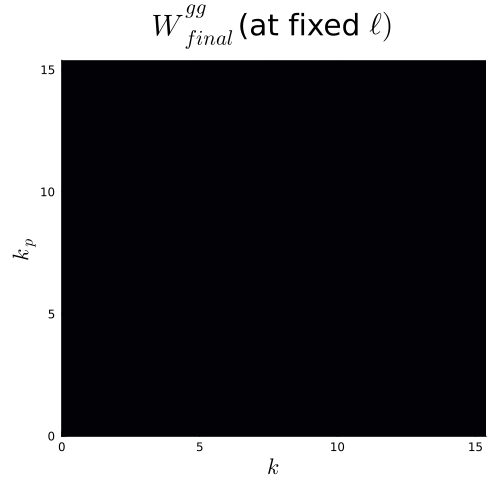

In [20]:
heatmap(sort(k_grid), sort(kp_grid), W_final_gal[1,:,:]./maximum(W_final_gal[1,:,:]), size = (500,500), title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)", 
    cgrad =:curl, xlabel=L"k",ylabel=L"k_p", legend=:none,
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)

In [21]:
savefig(joinpath(plot_subdir, "Sl_plots/k_grid_sorted_k_grid_sorted.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_01_160422/plots/Sl_plots/k_grid_sorted_k_grid_sorted.png"

In [22]:
println(size(W_tilde))

(96, 48, 101, 100)


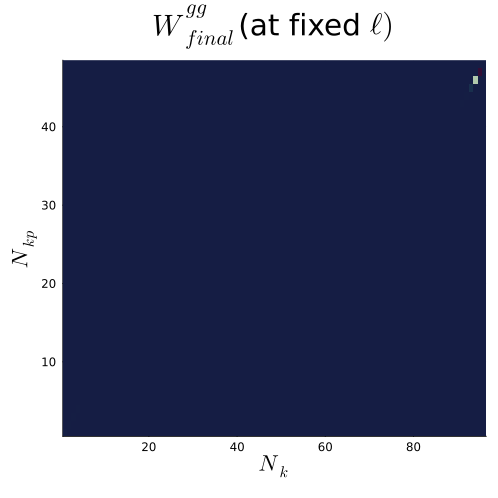

In [23]:
heatmap(1:Nk, 1:Nkp, W_final_gal[10,:,:]./(maximum(W_final_gal[10,:,:])), size = (500,500), title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)", 
    c =:curl , xlabel=L"N_k",ylabel=L"N_{kp}", legend=:none,
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)

In [24]:
savefig(joinpath(plot_subdir, "Sl_plots/Nk_Nkp.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_01_160422/plots/Sl_plots/Nk_Nkp.png"

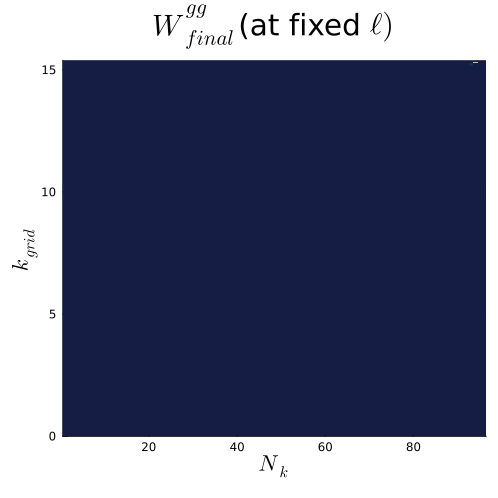

In [25]:
heatmap(1:Nk, sort(kp_grid), W_final_gal[10,:,:]./(maximum(W_final_gal[10,:,:])), size = (500,500), title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)", 
    c =:curl , xlabel=L"N_k",ylabel=L"k_{grid}", legend=:none,
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)

In [26]:
savefig(joinpath(plot_subdir, "Sl_plots/Nk_kp_grid_sorted.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_01_160422/plots/Sl_plots/Nk_kp_grid_sorted.png"

In [27]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z_pk = pk_dict["z"];
#Interpolating the power spectrum: Linear P(k) - Non-linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x_pk = LinRange(first(z_pk), last(z_pk), length(z_pk))
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x_pk, y))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x_pk, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));
# plot(k, power_spectrum.(k, 1000.0, 1000.0), 
#      label="Linear P(k)", 
#      xscale=:log10, 
#      yscale=:log10, 
#      title=L"$P(k)$ at $z=0$", titlefontsize=20,
#      xlabel=L"$k \; (h/\mathrm{Mpc})$", 
#      ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
#      labelfontsize=15)
# plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
#       label="Non-linear P(k)", 
#       xscale=:log10, 
#       yscale=:log10,
#       size=(800,600),
#       legendfontsize=10)

get_clencurt_grid produces the node of Clenshaw-Curtis mapped on [$k_{min}$, $k_{max}$]. \
get_clencurt_weights produces the corresponding quadrature weights scaled to the interval [-1,1]. \

In [28]:
Pk_grid = power_spectrum.(k_grid, kmin, kmax)
w_k = Blast.get_clencurt_weights(kmin, kmax, Nk)
weight_gal = w_k .* k_grid.^2 .* Pk_grid 
;

In [29]:
abstract type AbstractProbe end
struct Galaxy <: AbstractProbe end
struct Shear <: AbstractProbe end
factorial_frac(ℓ) = (ℓ + 2.0) * (ℓ + 1.0) * ℓ * (ℓ - 1.0)
get_ell_prefactor(::Galaxy, ::Galaxy, ℓ) = @. (2 / π) * ones(length(ℓ))
get_ell_prefactor(::Galaxy, ::Shear,  ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Galaxy, ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Shear,  ℓ) = @. (2 / π) * factorial_frac(ℓ)
pref_gg = get_ell_prefactor(Galaxy(), Galaxy(), ℓ)
pref_gg = reduce(vcat, pref_gg)
pref_gs = get_ell_prefactor(Galaxy(), Shear(), ℓ)
pref_gs = reduce(vcat, pref_gs)
pref_gg = reduce(vcat, pref_gg)
pref_ss = get_ell_prefactor(Shear(), Shear(), ℓ)
pref_ss = reduce(vcat, pref_ss);

In [30]:
println("SIZES")
println("weight_gal -> ", size(weight_gal))
println("W_final_gal -> ", size(W_final_gal))
println("pref_gg -> ", size(pref_gg), "\npref_ss -> ", size(pref_ss), "\npref_gs -> ", size(pref_gs))

SIZES
weight_gal -> (96,)
W_final_gal -> (100, 96, 48)
pref_gg -> (100,)
pref_ss -> (100,)
pref_gs -> (100,)


In [31]:
S_lkk_gg = zeros(Float64, size(W_final_gal, 3), size(W_final_gal, 3), length(ℓ))
# k1 and k2 are alredy inside the W_tilde (for now, equal to k. and also k1 = k2)
@tullio S_lkk_gg[kp, kpp, li] = pref_gg[li] * weight_gal[k] * W_final_gal[li, k, kp] * W_final_gal[li, k, kpp]
#@tullio S_lkk_gg[kp, kpp, li] = pref_gg[li] * weight_gal[k] * W_final_gal[li, k, kp] * W_final_gal[li, k, kpp] * kp_grid[kp] * kp_grid[kpp]
println("Size of S_l (kp, kpp) (gal-gal):  ", size(S_lkk_gg))
npzwrite(joinpath(quantity_subdir, "Sl/S_lkk_gg.npy"), S_lkk_gg)
;

Size of S_l (kp, kpp) (gal-gal):  (48, 48, 100)


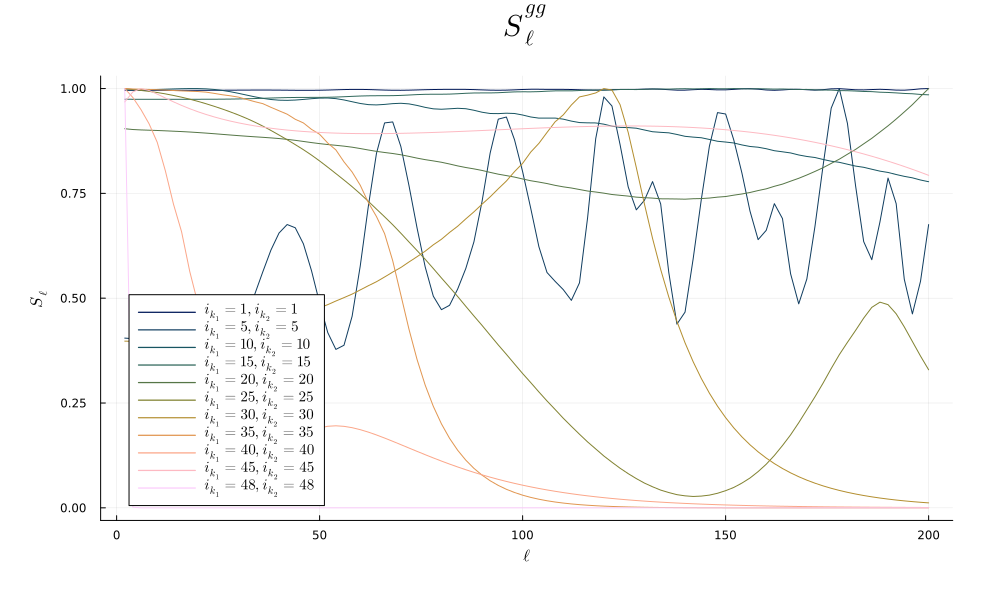

In [32]:
using Plots
using LaTeXStrings

idx_diag = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 48]

# palette continua, un colore per ogni curva, campionata in modo uniforme
colors = palette(:batlow, length(idx_diag))

plt = plot()
for (n, i) in enumerate(idx_diag)
    j = i
    plot!(plt, ℓ, S_lkk_gg[i,j,:]/maximum(S_lkk_gg[i,j,:]),
          label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)",
          color = colors[n])
end

plot!(plt, label="Beyond BLAST", 
    xlabel=L"\ell", ylabel=L"S_\ell", 
    title=L"S_\ell^{gg}",
    size=(1000, 600), titlefontsize=20, 
    legendfontsize=10, margin = 10mm)

plt


In [33]:
savefig(joinpath(plot_subdir, "Sl_plots/S_lkk_gg_fixed_l_various.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_01_160422/plots/Sl_plots/S_lkk_gg_fixed_l_various.png"

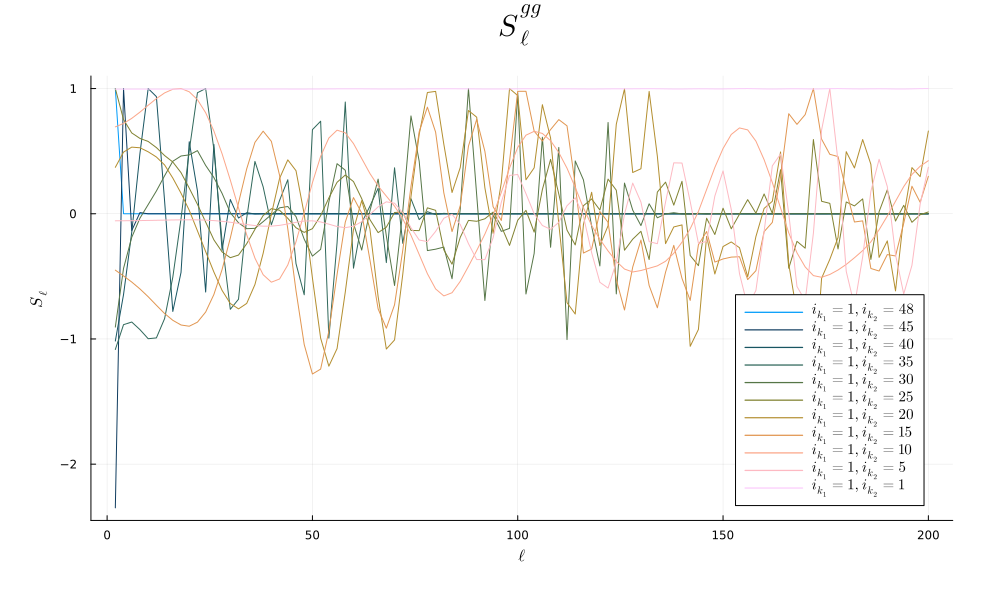

In [34]:
# plot
colors = palette(:batlow, length(idx_diag))
i, j = 1, 48
plot(ℓ, S_lkk_gg[i,j,:]/maximum(S_lkk_gg[i,j,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)", colors= colors[1])
i, j = 1, 45
plot!(ℓ, S_lkk_gg[i,j,:]/maximum(S_lkk_gg[i,j,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)", color = colors[2])
i, j = 1, 40
plot!(ℓ, S_lkk_gg[i,j,:]/maximum(S_lkk_gg[i,j,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)", color = colors[3])
i, j = 1, 35
plot!(ℓ, S_lkk_gg[i,j,:]/maximum(S_lkk_gg[i,j,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)", color = colors[4])
i, j = 1, 30
plot!(ℓ, S_lkk_gg[i,j,:]/maximum(S_lkk_gg[i,j,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)", color = colors[5])
i, j = 1, 25
plot!(ℓ, S_lkk_gg[i,j,:]/maximum(S_lkk_gg[i,j,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)", color = colors[6])
i, j = 1, 20
plot!(ℓ, S_lkk_gg[i,j,:]/maximum(S_lkk_gg[i,j,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)", color = colors[7])
i, j = 1, 15
plot!(ℓ, S_lkk_gg[i,j,:]/maximum(S_lkk_gg[i,j,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)", color = colors[8])
i, j = 1, 10
plot!(ℓ, S_lkk_gg[i,j,:]/maximum(S_lkk_gg[i,j,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)", color = colors[9])
i, j = 1, 5
plot!(ℓ, S_lkk_gg[i,j,:]/maximum(S_lkk_gg[i,j,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)", color = colors[10])
i, j = 1, 1
plot!(ℓ, S_lkk_gg[i,j,:]/maximum(S_lkk_gg[i,j,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)", color = colors[11])

plot!(label="Beyond BLAST", 
    xlabel=L"\ell", ylabel=L"S_\ell", 
    title=L"S_\ell^{gg}",
    size=(1000, 600), titlefontsize=20, 
    legendfontsize=10, margin = 10mm)

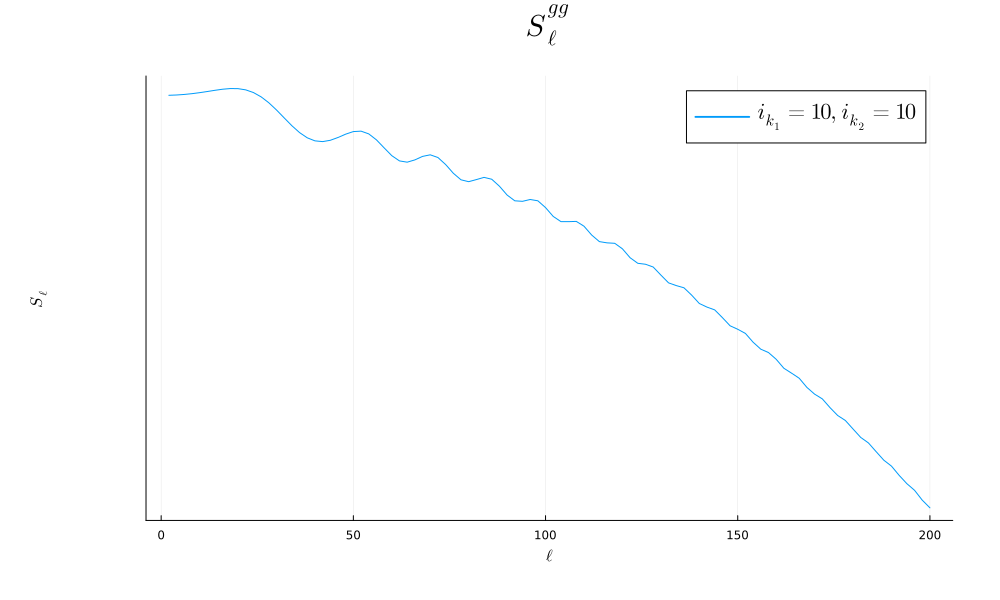

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [35]:
# plot
i = 10
j = 10
plot(ℓ, S_lkk_gg[10,10,:], label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)")

plot!(label="Beyond BLAST", 
    xlabel=L"\ell", ylabel=L"S_\ell", 
    title=L"S_\ell^{gg}",
    size=(1000, 600), titlefontsize=20, 
    legendfontsize=15, margin = 10mm)

In [36]:
# # plot
# i = 1
# j = 1
# p1 =  plot(ℓ, k1 * k2 * S_lkk_gg[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{gg} k_1 k_2")
# p2 =  plot(ℓ, S_lkk_gg[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{gg}")

# plot(p1, p2, layout = (1, 2), size=(2000, 600), titlefontsize=20, legendfontsize=10, margin = 10mm)

In [37]:
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_gg_and_k1k2.png"))

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_01_160422/plots/Sl_plots/S_l_plot_gg_and_k1k2.png"

In [38]:
println("k")
ka = Nk
println(k_grid[ka])
kb = Nk - 5
println(k_grid[kb])
kc = Nk - 10
println(k_grid[kc])
kd = Nk - 30
println(k_grid[kd])
ke = Nk - Nk + 3
println(k_grid[ke])
##################
println("kp")
kpa = Nkp
println(k_grid[kpa])
kpb = Nkp - 5
println(k_grid[kpb])
kpc = Nkp - 10
println(k_grid[kpc])
kpd = Nkp - 20
println(k_grid[kpd])
kpe = Nkp - Nkp + 3
println(k_grid[kpe])
;

k
0.0003571428607137071
0.10526775812389655
0.4171379158212458
3.4852904090315464
15.367797522875822
kp
7.819667501756577
9.083842689272462
10.310065300495225
12.516807794677481
15.367797522875822


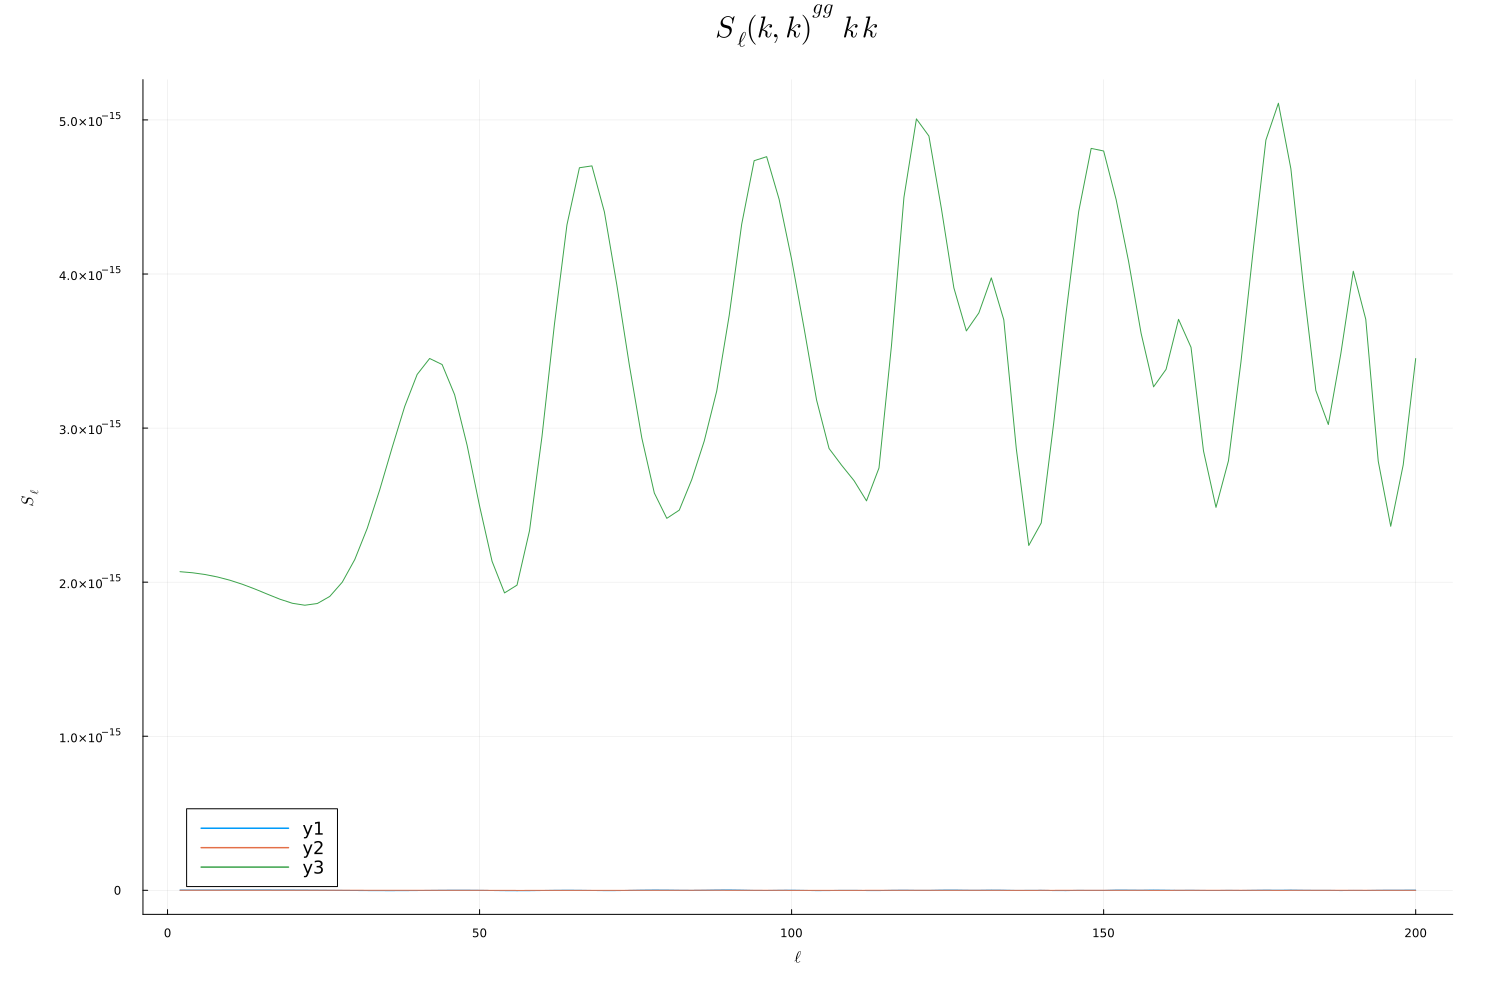

In [39]:
p = 
plot(ℓ, S_lkk_gg[2,20,:],
    #label="k = 0.000357 h/Mpc"
    )
plot!(p, ℓ, S_lkk_gg[10,22,:],
#     #label="k = 0.004562 h/Mpc"
     )
plot!(p, ℓ, S_lkk_gg[5,5,:],
#      #label="k = 0.017175 h/Mpc"
      )
# plot!(p, ℓ, S_lkk_gg[30,30,:],
#     #label="k = 0.151276 h/Mpc"
#     )
# plot!(p, ℓ, S_lkk_gg[10,10,:],
#     #label="k = 15.3846 h/Mpc"
#     )
plot!(p,
    xlabel=L"\ell",
    ylabel=L"S_\ell",
    size=(1500, 1000),
    title=L"S_\ell(k, k)^{gg} \ k\,k",
    titlefontsize=20,
    legendfontsize=12,
    margin=10mm)
plot!(p, legendposition=:bottomleft)

In [40]:
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_gg_different_ks.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_01_160422/plots/Sl_plots/S_l_plot_gg_different_ks.png"

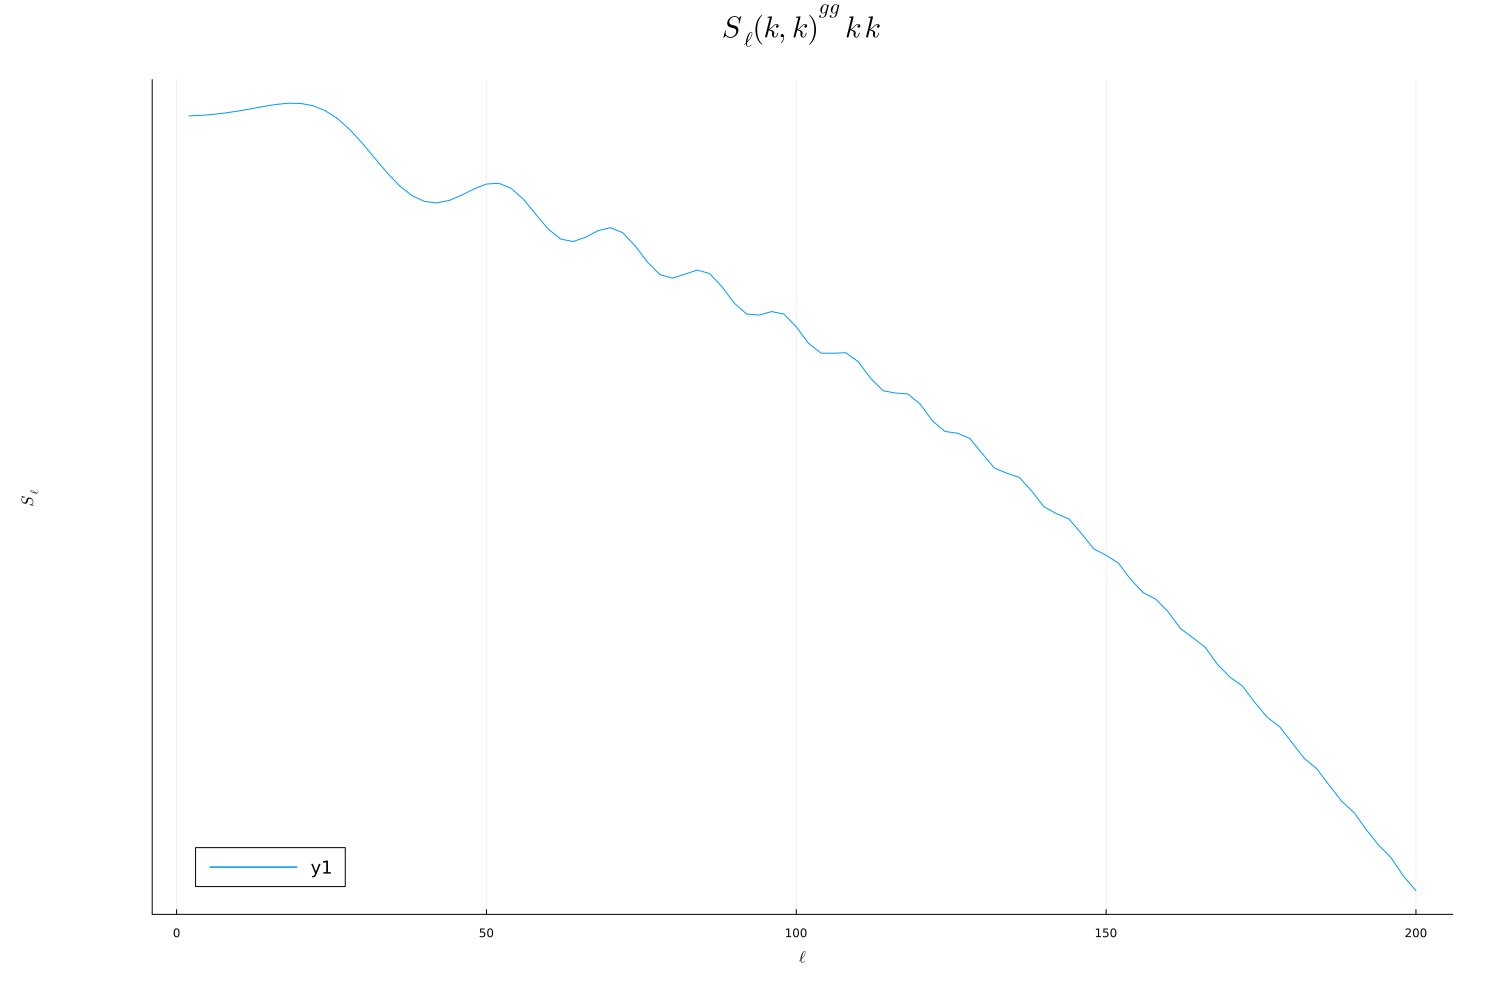

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [41]:
i = 10
j = 10

p = plot(ℓ, S_lkk_gg[10,10,:],
    #label="k1 = 0.000357 h/Mpc e k2 = 0.004562 h/Mpc",
    xlabel=L"\ell",
    ylabel=L"S_\ell",
    title=L"S_\ell(k, k)^{gg} \, k\,k")
# plot!(p, ℓ, S_lkk_gg[50,70,:],
#     label="k1 = 0.004562 h/Mpc e k2 = 0.017175 h/Mpc")
# plot!(p, ℓ, S_lkk_gg[30,50,:],
#     label="k1 = 0.017175 h/Mpc e k2 = 0.151276 h/Mpc")
# plot!(p, ℓ, S_lkk_gg[10,30,:],
#     label="k1 = 0.000357 h/Mpc e k2 = 0.151276 h/Mpc")
# plot!(p, ℓ, S_lkk_gg[i,j,:],
#     label="k1 = 0.000357 h/Mpc e k2 = 15.3846 h/Mpc")
plot!(p,
    size=(1500, 1000),
    titlefontsize=20,
    legendfontsize=12,
    margin=10mm,
    legendposition=:bottomleft)

In [42]:
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_gg_different_k_and_ks.png"))

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_01_160422/plots/Sl_plots/S_l_plot_gg_different_k_and_ks.png"

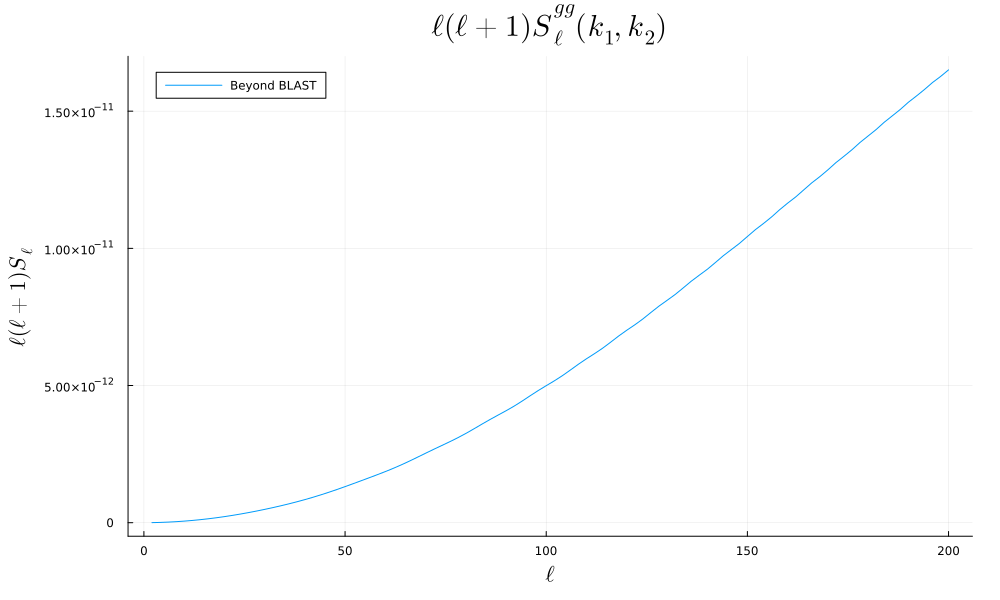

In [43]:
plot(
    ℓ,
    S_lkk_gg[10, 10, :] .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell^{gg}(k_1,k_2)",
    markersize=4,
    size = (1000, 600),
    titlefontsize=20,
    labelfontsize=15,
    margin = 5mm
)

In [44]:
println(size(S_lkk_gg))

(48, 48, 100)


Size of S_lkk_gg: (48, 48, 100)
Size of diagS: (100,)
Size of k_grid: (96,)


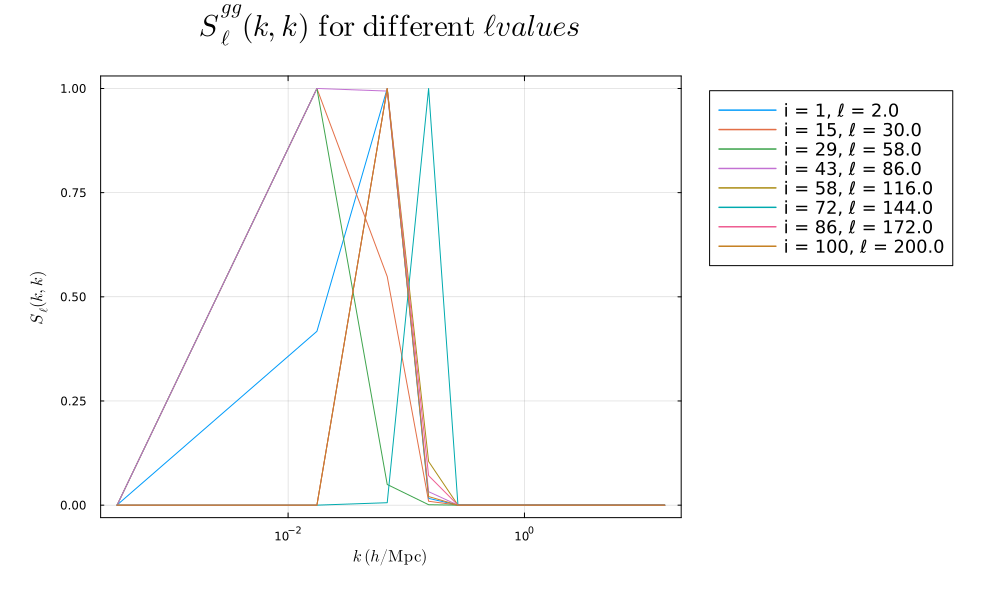

In [45]:
# S_lkk ha dimensioni (k1, k2, ℓ) = [Nk,Nkp,100]
# k_grid deve avere lunghezza Nk
# ℓ deve avere lunghezza 100

diagS = [diag(@view S_lkk_gg[:, :, i]) for i in 1:size(S_lkk_gg, 3)]
println("Size of S_lkk_gg: ", size(S_lkk_gg))
println("Size of diagS: ", size(diagS))
println("Size of k_grid: ", size(k_grid))
nshow = 8
idx = round.(Int, range(1, size(S_lkk_gg, 3), length=nshow))

p = plot(
    xscale = :log10,
    xlabel = L"k \; (h/\mathrm{Mpc})",
    ylabel = L"S_\ell(k,k)",
    title  = L"S_\ell^{gg}(k,k)\ \mathrm{for\ different}\ \ell values",
    legend = :topright,
    framestyle = :box,
    grid = true,
    lw = 2,
    size = (1000, 600),
    titlefontsize = 20,
    legendfontsize = 12,
    margin = 10mm,
    legendposition = :outertopright
)

for i in idx
    plot!(p, kp_grid, diagS[i]/maximum(diagS[i]), label = "i = $i, ℓ = $(round(ℓ[i], digits=2))")
end

display(p)

In [46]:
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_ll+1.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_01_160422/plots/Sl_plots/S_l_plot_ll+1.png"

In [47]:
# heatmap(ℓ, log10.(sort(k_grid)), S_lkk_gg[1,:,:], ylabel=L"\log_{10}(k \; (h/\mathrm{Mpc}))", xlabel=L"\ell", title=L"S_{lkk}^{gg}", margin = 10mm, size =(1000, 600))

In [48]:
# heatmap(log10.(sort(k_grid)), log10.(sort(k_grid)), S_lkk_gg[:,:,1], ylabel=L"\log_{10}(k \; (h/\mathrm{Mpc}))", xlabel=L"\ell", title=L"S_{lkk}^{gg}", margin = 10mm, size =(1000, 600))

In [49]:
# #heatmap(k_grid, ℓ, S_lkk_gg[:,1,:], xlabel=L"k \; (h/\mathrm{Mpc})", ylabel=L"\ell", title=L"S_{lkk}^{gg}", margin = 10mm, size =(1000, 600))
# #if i want it into log
# heatmap(sort(k_grid), ℓ, S_lkk_gg[:,1,:], xlabel=L"\log_{10}(\mathrm{k} \; (h/\mathrm{Mpc}))", ylabel=L"\ell", title=L"S_{lkk}^{gg}", margin = 10mm, size =(1000, 600))

In [50]:
# # S_lkk ha dimensioni (k1, k2, ℓ) = [96,96,100]
# # k_grid deve avere lunghezza 96
# # ℓ deve avere lunghezza 100

# diagS = [diag(@view S_lkk_gg[:, :, i]) for i in 1:size(S_lkk_gg, 3)]
# print(size(diagS))
# nshow = 8
# idx = round.(Int, range(1, size(S_lkk_gg, 3), length=nshow))

# p = plot(
#     xscale = :log10,
#     xlabel = L"k \; (h/\mathrm{Mpc})",
#     ylabel = L"S_\ell(k,k)",
#     title  = L"S_\ell^{gg}(k,k)\ \mathrm{for\ different}\ \ell values",
#     legend = :topright,
#     framestyle = :box,
#     grid = true,
#     lw = 2,
#     size = (1000, 600),
#     titlefontsize = 20,
#     legendfontsize = 12,
#     margin = 10mm,
#     legendposition = :outertopright
# )

# for i in idx
#     plot!(p, k_grid, diagS[i], label = "ℓ=$(i)")

# end

# display(p)

---